<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/12_causal_time_series_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12 실습: 시계열 인과추론 입문
**Notebook:** `12_causal_time_series_intro.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 시계열에서 **예측(Forecasting)** 과 **인과추론(Causal Inference)** 의 차이를 이해합니다.
2. 개입 전후 비교만으로는 왜 정책 효과를 정확히 말하기 어려운지 확인합니다.
3. **Counterfactual(반사실)** 의 개념을 데이터로 직관적으로 이해합니다.
4. 단일 시계열의 **Interrupted Time Series (ITS)** 아이디어를 확인합니다.
5. 처리집단과 비교집단을 함께 쓰는 **Comparative ITS / Time-series DID** 형태의 회귀를 구현합니다.
6. 수준 변화(level change)와 기울기 변화(slope change)를 구분해서 해석합니다.
7. HAC(Newey–West) 표준오차를 사용해 자기상관을 고려한 추정을 수행합니다.

---

## 왜 이 실습이 중요한가?
시계열 분석에서 “앞으로 얼마가 될까?”를 묻는 것은 예측 문제입니다.  
반면 “정책이나 개입이 실제로 변화를 만들어냈는가?”를 묻는 것은 인과추론 문제입니다.

이 둘은 비슷해 보이지만 질문의 구조가 다릅니다.

- 예측은 미래값의 정확한 추정이 목적입니다.
- 인과추론은 **개입이 없었더라면 어땠을까?** 라는 반사실적 질문이 핵심입니다.

이번 실습의 목적은 복잡한 최신 인과 모형을 모두 다루는 것이 아니라,  
시계열 인과추론의 출발점인 **반사실, 비교집단, 수준 변화, 기울기 변화, 자기상관 고려**를 실제 코드로 이해하는 데 있습니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [2]:
# ============================================
# 2. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 2. 실습용 데이터 생성
이번 실습에서는 교육 목적상 **treated series** 와 **control series** 를 포함한 synthetic monthly data를 사용합니다.

구조는 다음과 같습니다.

- 공통 추세(common trend)
- 공통 계절성(common seasonality)
- 공통 충격(common shocks)
- 2022년 1월부터 처리집단에만 발생하는 정책 효과
  - 즉시 수준 변화(level change)
  - 이후 기울기 변화(slope change)

이 설정을 통해 단순 전후 비교가 왜 위험한지, 비교집단이 왜 중요한지 직관적으로 확인할 수 있습니다.


In [3]:
# ============================================
# 3. Synthetic treated/control time series 생성
# ============================================

np.random.seed(123)

dates = pd.date_range(start="2018-01-31", periods=84, freq="M")
n = len(dates)
t = np.arange(n)

intervention_date = pd.Timestamp("2022-01-31")
post = (dates >= intervention_date).astype(int)
post_time = np.where(dates >= intervention_date, np.arange(n) - np.where(dates == intervention_date)[0][0] + 1, 0)

# 공통 추세와 계절성
common_trend = 120 + 0.5 * t
seasonality = 5 * np.sin(2 * np.pi * t / 12) + 2 * np.cos(2 * np.pi * t / 12)

# 공통 충격
common_noise = np.random.normal(0, 2.0, n)

# 통제집단
control = common_trend + seasonality + common_noise + np.random.normal(0, 1.5, n)

# 처리집단: 개입 전에는 통제집단과 비슷하나, 개입 후 수준/기울기 변화 발생
treated = (
    common_trend
    + seasonality
    + common_noise
    + 3                                  # treat-specific baseline difference
    + np.random.normal(0, 1.5, n)
    + 8 * post                           # level change after intervention
    + 0.35 * post_time                   # slope change after intervention
)

df = pd.DataFrame({
    "date": np.tile(dates, 2),
    "group": ["treated"] * n + ["control"] * n,
    "y": np.concatenate([treated, control])
})

df["treated"] = (df["group"] == "treated").astype(int)
df["time"] = df.groupby("group").cumcount()
df["post"] = (df["date"] >= intervention_date).astype(int)

intervention_time_index = np.where(dates == intervention_date)[0][0]
df["post_time"] = np.where(df["date"] >= intervention_date, df["time"] - intervention_time_index + 1, 0)

display(df.head())


,date,group,y,treated,time,post,post_time
0,2018-01-31,treated,122.947579,1,0,0,0
1,2018-02-28,treated,129.315147,1,1,0,0
2,2018-03-31,treated,128.322596,1,2,0,0
3,2018-04-30,treated,126.374730,1,3,0,0
4,2018-05-31,treated,126.061706,1,4,0,0


## 3. 데이터 구조 확인
우리는 지금 두 개의 월별 시계열을 가지고 있습니다.

- **treated**: 정책이나 개입의 영향을 받은 집단
- **control**: 비슷한 환경을 공유하지만 개입은 받지 않은 집단

시계열 인과추론의 핵심은, 단순히 “개입 전후 treated 값이 바뀌었는가?”를 보는 것이 아니라  
**control과 비교했을 때 treated가 추가적으로 얼마나 달라졌는가**를 묻는 데 있습니다.


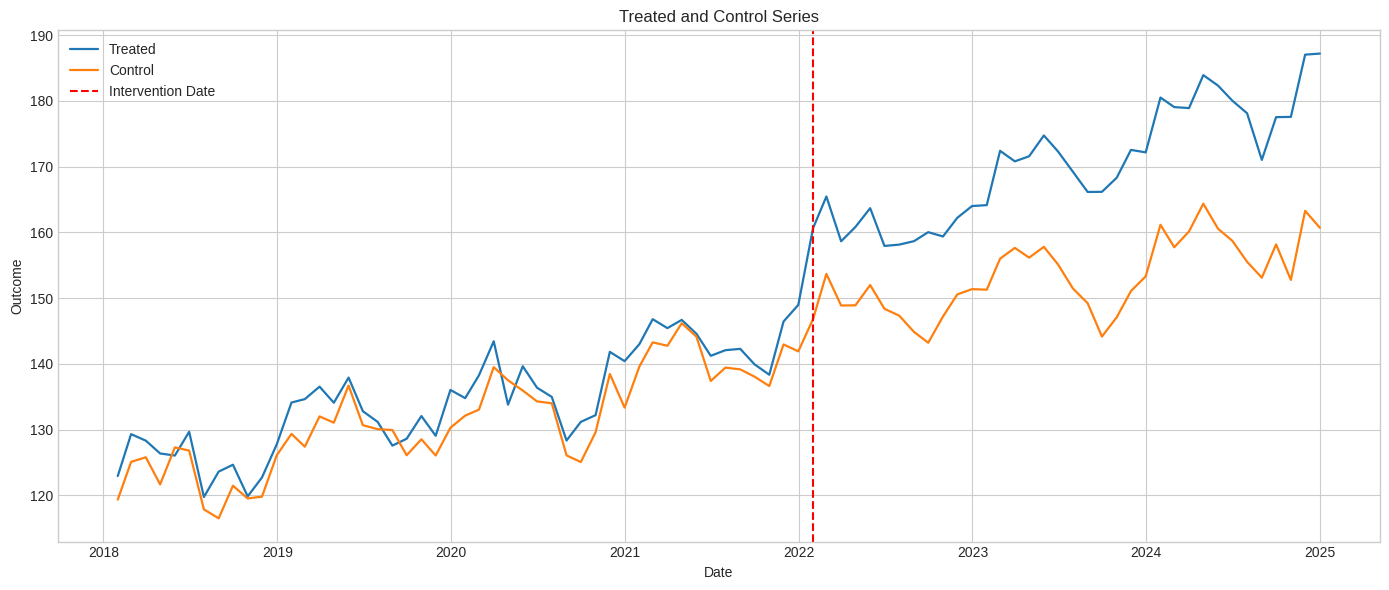

In [4]:
# ============================================
# 4. Treated / Control 시계열 플롯
# ============================================

pivot = df.pivot(index="date", columns="group", values="y")

plt.figure(figsize=(14, 6))
plt.plot(pivot.index, pivot["treated"], label="Treated", linewidth=1.6)
plt.plot(pivot.index, pivot["control"], label="Control", linewidth=1.6)
plt.axvline(intervention_date, color="red", linestyle="--", label="Intervention Date")

plt.title("Treated and Control Series")
plt.xlabel("Date")
plt.ylabel("Outcome")
plt.legend()
plt.tight_layout()
plt.show()


## 4. 단순 전후 비교의 한계
이제 가장 단순한 분석을 해 보겠습니다.  
treated 집단에 대해 개입 전 평균과 개입 후 평균을 비교합니다.

이 방법은 직관적이지만 중요한 문제가 있습니다.

- 시간 추세를 무시함
- 계절성을 무시함
- 외부 공통 충격을 무시함
- 개입이 없어도 증가했을 가능성을 배제하지 못함

즉, 이 방식은 **인과 효과**가 아니라 단순한 **전후 차이(before-after difference)** 에 가깝습니다.


In [5]:
# ============================================
# 5. Treated 집단의 단순 전후 평균 비교
# ============================================

treated_df = df.loc[df["treated"] == 1].copy()

before_mean = treated_df.loc[treated_df["post"] == 0, "y"].mean()
after_mean = treated_df.loc[treated_df["post"] == 1, "y"].mean()

simple_effect = after_mean - before_mean

summary_simple = pd.DataFrame({
    "Before_Mean": [before_mean],
    "After_Mean": [after_mean],
    "Simple_BeforeAfter_Diff": [simple_effect]
})

display(summary_simple)


,Before_Mean,After_Mean,Simple_BeforeAfter_Diff
0,134.51697,170.373753,35.856783


## 5. 반사실(counterfactual)의 개념
인과추론에서 진짜로 알고 싶은 것은 다음 질문입니다.

> 개입이 있었던 실제 세계의 treated 값  
> **vs**  
> 개입이 없었더라면 같은 시점에 treated가 보였을 값

하지만 두 세계를 동시에 관측할 수는 없습니다.  
따라서 우리는 control series, 추세, 계절성, 사전 패턴 등을 이용해 **반사실(counterfactual)** 을 추정해야 합니다.

이번 실습에서는 이를 위해 다음 두 단계를 거칩니다.

1. treated만 사용하는 **Interrupted Time Series (ITS)** 직관 확인
2. treated + control을 같이 쓰는 **Comparative ITS / Time-series DID** 회귀 적합


## 6. 단일 시계열 ITS 직관
먼저 treated 시계열 하나만 놓고, 시간 추세와 개입 더미를 사용해 segmented regression을 적합합니다.

핵심 변수는 다음과 같습니다.

- `time`: 전체 시간 추세
- `post`: 개입 이후 수준 변화
- `post_time`: 개입 이후 기울기 변화

이 접근은 control이 없을 때 유용한 출발점이지만,  
동시에 일어난 외부 충격과 공통 변화를 충분히 통제하지 못할 수 있습니다.


In [6]:
# ============================================
# 6. 단일 시계열 ITS 회귀
# ============================================

import statsmodels.api as sm

its_df = treated_df.copy()
its_df["month"] = its_df["date"].dt.month.astype("category")

X_its = its_df[["time", "post", "post_time"]].copy()
month_dummies_its = pd.get_dummies(its_df["month"], prefix="m", drop_first=True, dtype=float)
X_its = pd.concat([X_its, month_dummies_its], axis=1)
X_its = sm.add_constant(X_its)

its_model = sm.OLS(its_df["y"], X_its).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print(its_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     2103.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           6.87e-85
Time:                        02:44:11   Log-Likelihood:                -188.27
No. Observations:                  84   AIC:                             406.5
Df Residuals:                      69   BIC:                             443.0
Df Model:                          14                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        125.0435      0.949    131.761      0.0

## 7. 단일 ITS 해석
단일 ITS에서 특히 중요한 계수는 다음 둘입니다.

- `post`: 개입 직후의 **즉시 수준 변화**
- `post_time`: 개입 이후의 **추세 변화**

하지만 이 결과는 여전히 조심해서 해석해야 합니다.  
왜냐하면 같은 시점에 다른 외생 충격이 발생했다면, 그 변화까지 개입 효과처럼 보일 수 있기 때문입니다.

따라서 더 설득력 있는 시계열 인과추론을 위해서는, 가능한 경우 비교집단(control series)을 함께 쓰는 것이 바람직합니다.


## 8. Comparative ITS / Time-series DID 회귀
이제 treated와 control을 함께 사용합니다.

회귀식의 핵심 아이디어는 다음과 같습니다.

- 시간 추세(time)
- 개입 이후(post)
- treated 여부(treated)
- treated × post : 개입 이후 treated의 추가 수준 변화
- treated × post_time : 개입 이후 treated의 추가 기울기 변화

즉, 단순한 DID보다 한 단계 더 나아가 **수준 변화와 추세 변화를 동시에 분리**하는 형태입니다.


In [7]:
# ============================================
# 7. Comparative ITS / Time-series DID 설계행렬
# ============================================

panel_df = df.copy()
panel_df["month"] = panel_df["date"].dt.month.astype("category")
panel_df["treated_post"] = panel_df["treated"] * panel_df["post"]
panel_df["treated_post_time"] = panel_df["treated"] * panel_df["post_time"]

X = panel_df[["time", "treated", "post", "post_time", "treated_post", "treated_post_time"]].copy()
month_dummies = pd.get_dummies(panel_df["month"], prefix="m", drop_first=True, dtype=float)
X = pd.concat([X, month_dummies], axis=1)
X = sm.add_constant(X)

display(X.head())


,const,time,treated,post,post_time,treated_post,treated_post_time,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12
0,1.0,0,1,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1,1,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,2,1,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,3,1,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,4,1,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
# ============================================
# 8. Comparative ITS / Time-series DID 회귀 적합
# ============================================

causal_model = sm.OLS(panel_df["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(causal_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     1910.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):          6.04e-166
Time:                        02:44:12   Log-Likelihood:                -382.04
No. Observations:                 168   AIC:                             800.1
Df Residuals:                     150   BIC:                             856.3
Df Model:                          17                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               121.8356      0.67

## 9. 핵심 계수 해석
이 회귀에서 특히 중요한 계수는 다음 둘입니다.

- `treated_post`  
  : control과 비교했을 때, 개입 직후 treated에만 추가적으로 발생한 **수준 변화**

- `treated_post_time`  
  : control과 비교했을 때, 개입 이후 treated에만 추가적으로 발생한 **기울기 변화**

즉, 이 두 계수가 우리가 찾고 있는 시계열 인과효과의 핵심 요약치입니다.


In [9]:
# ============================================
# 9. 핵심 계수만 보기 좋게 정리
# ============================================

coef_table = pd.DataFrame({
    "coef": causal_model.params,
    "pvalue": causal_model.pvalues
})

key_terms = ["treated_post", "treated_post_time"]
display(coef_table.loc[key_terms])


,coef,pvalue
treated_post,6.919680,2.172913e-17
treated_post_time,0.388811,6.616842e-27


## 10. treated와 control의 사전 추세(pre-trend) 점검
인과적 해석을 더 설득력 있게 하려면, 개입 이전에 treated와 control이 너무 다른 방향으로 움직이지 않았는지 확인하는 것이 좋습니다.

여기서는 간단히 개입 이전 구간만 따로 그려서 시각적으로 확인합니다.


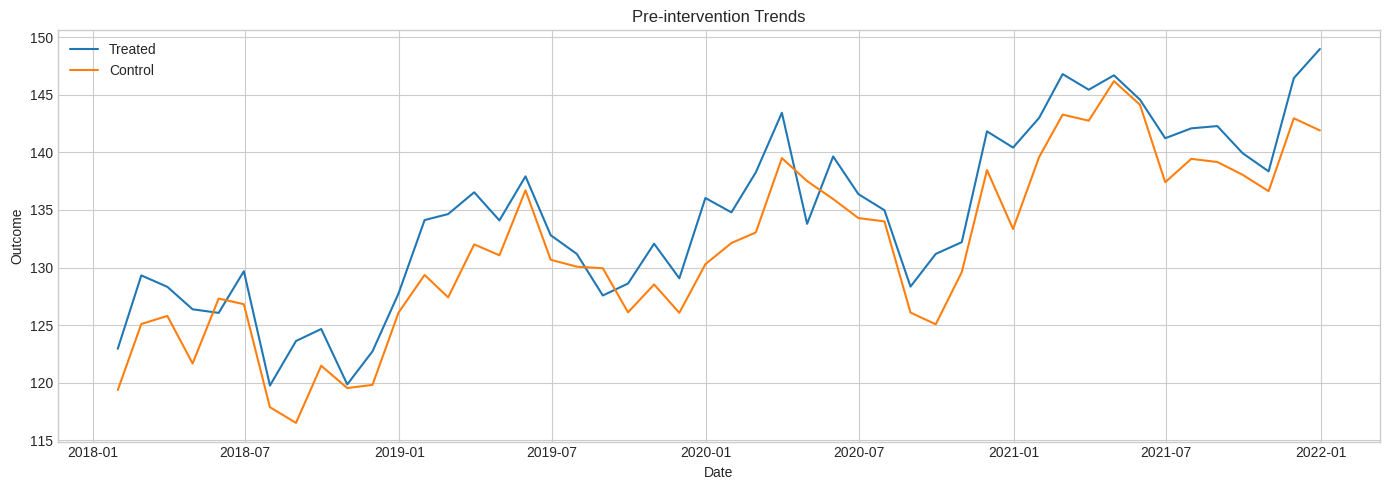

In [10]:
# ============================================
# 10. Intervention 이전 구간만 시각화
# ============================================

pre_period = pivot.loc[pivot.index < intervention_date]

plt.figure(figsize=(14, 5))
plt.plot(pre_period.index, pre_period["treated"], label="Treated", linewidth=1.5)
plt.plot(pre_period.index, pre_period["control"], label="Control", linewidth=1.5)

plt.title("Pre-intervention Trends")
plt.xlabel("Date")
plt.ylabel("Outcome")
plt.legend()
plt.tight_layout()
plt.show()


## 11. 반사실(counterfactual) 경로 만들기
이제 회귀 결과를 이용해 treated 집단의 개입 후 반사실 경로를 만들어 보겠습니다.

아이디어는 다음과 같습니다.

- 실제 treated 시계열은 개입 효과를 포함
- 반사실 treated 시계열은
  - treated는 유지하되
  - `treated_post = 0`
  - `treated_post_time = 0`
  로 두어 “개입이 없었더라면”의 경로를 계산

이렇게 하면 개입 이후 실제값과 반사실값의 차이를 시각적으로 비교할 수 있습니다.


In [11]:
# ============================================
# 11. Counterfactual path for treated
# ============================================

treated_panel = panel_df.loc[panel_df["treated"] == 1].copy()

X_actual_treated = X.loc[treated_panel.index].copy()
X_counterfactual_treated = X_actual_treated.copy()

# 개입이 없었더라면 treated_post, treated_post_time 효과를 제거
X_counterfactual_treated["treated_post"] = 0
X_counterfactual_treated["treated_post_time"] = 0

treated_panel["fitted_actual"] = causal_model.predict(X_actual_treated)
treated_panel["counterfactual"] = causal_model.predict(X_counterfactual_treated)

display(treated_panel[["date", "y", "fitted_actual", "counterfactual"]].tail())


,date,y,fitted_actual,counterfactual
79,2024-08-31,171.027284,176.328019,156.966378
80,2024-09-30,177.532673,177.151271,157.400818
81,2024-10-31,177.567430,177.752013,157.612748
82,2024-11-30,187.036169,182.659030,162.130955
83,2024-12-31,187.199255,184.318120,163.401233


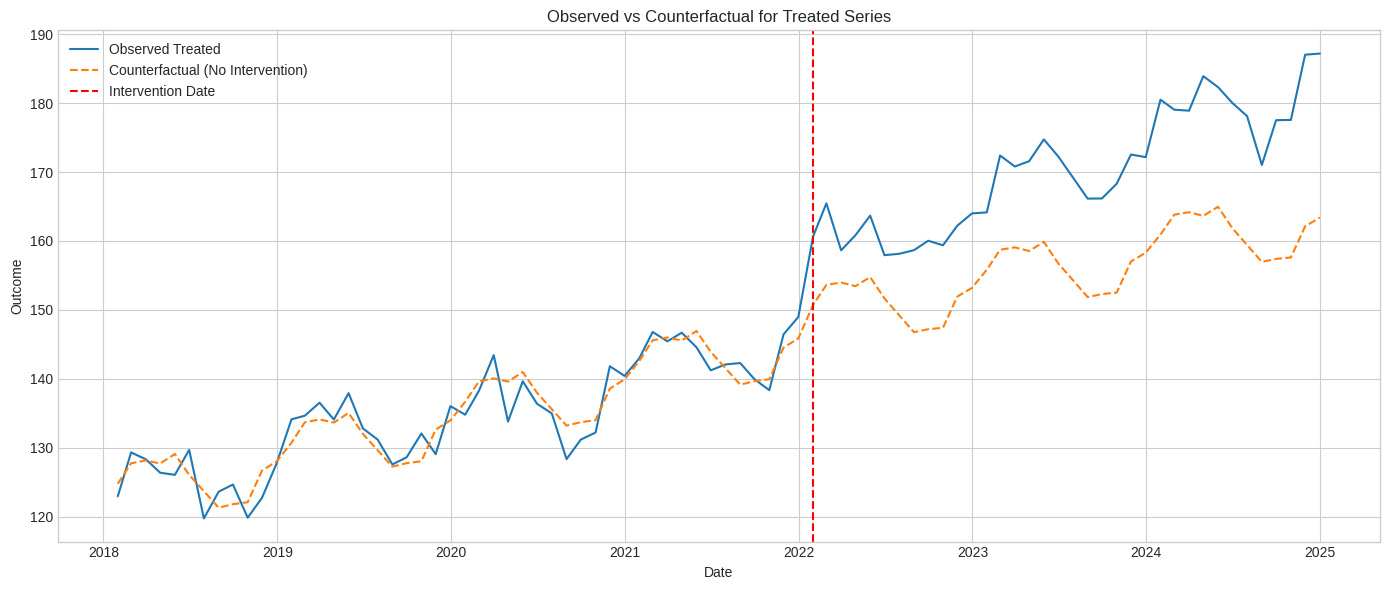

In [12]:
# ============================================
# 12. Actual vs Counterfactual plot
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(treated_panel["date"], treated_panel["y"], label="Observed Treated", linewidth=1.5)
plt.plot(treated_panel["date"], treated_panel["counterfactual"], label="Counterfactual (No Intervention)", linewidth=1.5, linestyle="--")
plt.axvline(intervention_date, color="red", linestyle="--", label="Intervention Date")

plt.title("Observed vs Counterfactual for Treated Series")
plt.xlabel("Date")
plt.ylabel("Outcome")
plt.legend()
plt.tight_layout()
plt.show()


## 12. 개입 이후 평균 효과 계산
반사실 경로가 있으면 개입 이후 구간에서 실제값과 반사실값의 차이를 평균하여 **post-period average treatment effect**에 가까운 값을 계산할 수 있습니다.


In [13]:
# ============================================
# 13. Post-period average effect
# ============================================

post_treated = treated_panel.loc[treated_panel["date"] >= intervention_date].copy()
post_treated["effect"] = post_treated["y"] - post_treated["counterfactual"]

effect_summary = pd.DataFrame({
    "Average_Post_Period_Effect": [post_treated["effect"].mean()],
    "Median_Post_Period_Effect": [post_treated["effect"].median()],
    "Max_Post_Period_Effect": [post_treated["effect"].max()]
})

display(effect_summary)


,Average_Post_Period_Effect,Median_Post_Period_Effect,Max_Post_Period_Effect
0,14.112689,13.966419,24.905215


## 13. Placebo intervention idea
좋은 인과 설계인지 점검하는 한 가지 방법은 **placebo date**를 넣어 보는 것입니다.  
즉, 실제 개입보다 이전 시점에 가짜 개입일을 두고 같은 회귀를 돌려 보았을 때, 큰 효과가 나오지 않는 것이 바람직합니다.

여기서는 간단히 placebo intervention date를 2020-01로 두고 핵심 계수를 비교합니다.


In [14]:
# ============================================
# 14. Placebo intervention test
# ============================================

placebo_date = pd.Timestamp("2020-01-31")

placebo_df = df.copy()
placebo_df["post_placebo"] = (placebo_df["date"] >= placebo_date).astype(int)

placebo_time_index = np.where(dates == placebo_date)[0][0]
placebo_df["post_time_placebo"] = np.where(
    placebo_df["date"] >= placebo_date,
    placebo_df["time"] - placebo_time_index + 1,
    0
)

placebo_df["treated_post_placebo"] = placebo_df["treated"] * placebo_df["post_placebo"]
placebo_df["treated_post_time_placebo"] = placebo_df["treated"] * placebo_df["post_time_placebo"]
placebo_df["month"] = placebo_df["date"].dt.month.astype("category")

X_placebo = placebo_df[["time", "treated", "post_placebo", "post_time_placebo",
                        "treated_post_placebo", "treated_post_time_placebo"]].copy()

month_dummies_placebo = pd.get_dummies(placebo_df["month"], prefix="m", drop_first=True, dtype=float)
X_placebo = pd.concat([X_placebo, month_dummies_placebo], axis=1)
X_placebo = sm.add_constant(X_placebo)

placebo_model = sm.OLS(placebo_df["y"], X_placebo).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

placebo_coef = pd.DataFrame({
    "coef": placebo_model.params,
    "pvalue": placebo_model.pvalues
})

display(placebo_coef.loc[["treated_post_placebo", "treated_post_time_placebo"]])


,coef,pvalue
treated_post_placebo,-4.484107,9.117284e-04
treated_post_time_placebo,0.425034,3.117585e-38


## 14. 예측과 인과를 다시 구분하기
여기서 한 가지 중요한 점을 다시 강조해야 합니다.

- 이 회귀는 예측 모델처럼 사용할 수도 있습니다.
- 그러나 이번 장의 핵심은 미래값 예측보다 **개입의 효과를 반사실과 비교해 해석하는 것**입니다.

즉, causal time series에서 가장 중요한 것은 RMSE를 조금 더 낮추는 것보다,  
**개입이 없었더라면 어떤 경로를 보였을지 설득력 있게 제시하는 것**입니다.


## 15. 자주 발생하는 실수 (Common Mistakes)
이번 장에서 특히 자주 발생하는 실수는 다음과 같습니다.

1. **예측과 인과를 혼동하는 실수**  
   잘 맞는 예측 모델이 반드시 좋은 인과 모형은 아닙니다.

2. **단순 전후 비교를 인과효과로 해석하는 실수**  
   추세, 계절성, 공통 충격이 있으면 전후 차이는 쉽게 왜곡될 수 있습니다.

3. **비교집단 없이 강한 인과 결론을 내리는 실수**  
   단일 ITS는 유용하지만, 동시적 외생 충격을 충분히 통제하지 못할 수 있습니다.

4. **자기상관을 무시한 표준오차를 사용하는 실수**  
   시계열 회귀에서는 HAC(Newey–West) 같은 보정이 중요할 수 있습니다.

5. **placebo나 사전 추세 점검 없이 결과를 확정하는 실수**  
   설계의 타당성을 확인하는 보조 검정이 필요합니다.


## 16. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- 시계열 인과추론의 핵심 질문은 반사실(counterfactual)이다.
- 단순한 before-after 차이는 인과효과가 아니라 단순 변화일 수 있다.
- Interrupted Time Series는 단일 시계열 개입 분석의 출발점이다.
- Comparative ITS / Time-series DID는 control series를 함께 사용해 더 설득력 있는 비교를 제공한다.
- 수준 변화(level change)와 기울기 변화(slope change)는 분리해서 해석해야 한다.
- HAC 표준오차와 placebo 점검은 결과의 신뢰성을 높이는 데 도움이 된다.


## 17. 연습문제 (Exercises)

1. intervention date를 다른 시점으로 바꾸었을 때 `treated_post`와 `treated_post_time` 계수가 어떻게 달라지는지 비교하시오.

2. control series 없이 단일 ITS만 사용했을 때와 comparative ITS를 사용했을 때 결과 차이를 비교하시오.

3. seasonality를 모델에서 제거하지 않으면 개입 효과 추정이 어떻게 달라질 수 있는지 설명하시오.

4. placebo intervention에서 유의한 효과가 계속 나온다면, 원래 설계에 어떤 문제가 있을 가능성이 있는지 논의하시오.

5. 실제 정책평가 데이터에서 control group을 선택할 때 어떤 기준을 사용해야 하는지 설명하시오.
